In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/cleaned_expenses.csv")
df.head()


,Date,Category,Amount,Type,Month,Weekday
0,2024-01-01,Shopping,960,Expense,January,Monday
1,2024-01-02,Bills,3192,Expense,January,Tuesday
2,2024-01-02,Rent,4526,Expense,January,Tuesday
3,2024-01-03,Shopping,3019,Expense,January,Wednesday
4,2024-01-04,Bills,869,Expense,January,Thursday


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      139 non-null    object
 1   Category  139 non-null    object
 2   Amount    139 non-null    int64 
 3   Type      139 non-null    object
 4   Month     139 non-null    object
 5   Weekday   139 non-null    object
dtypes: int64(1), object(5)
memory usage: 6.6+ KB


,Amount
count,139.000000
mean,6826.446043
std,11477.843075
min,216.000000
25%,1793.000000
50%,3004.000000
75%,4236.500000
max,48666.000000


In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()
df["Weekday"] = df["Date"].dt.day_name()

In [6]:
category = df[df["Type"]=="Expense"].groupby("Category")["Amount"].sum()
category.sort_values(ascending=False)

Category
Rent             66756
Food             66118
Shopping         49560
Entertainment    47729
Travel           45794
Bills            45219
Name: Amount, dtype: int64

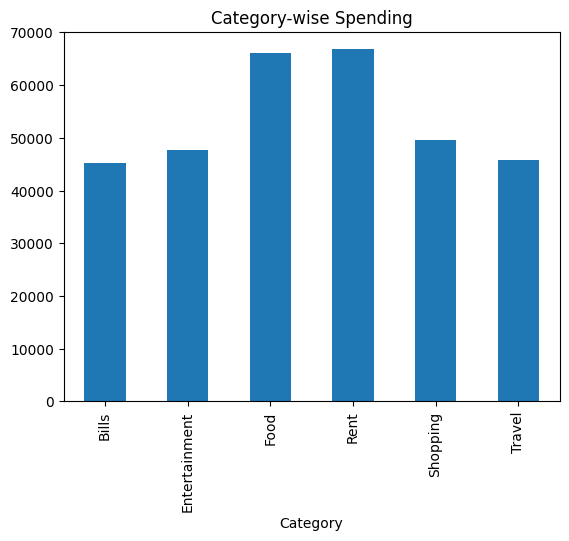

In [7]:
category.plot(kind="bar", title="Category-wise Spending")
plt.show()

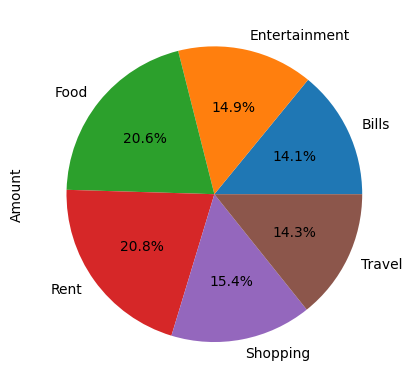

In [8]:
category.plot(kind="pie", autopct="%1.1f%%")
plt.show()

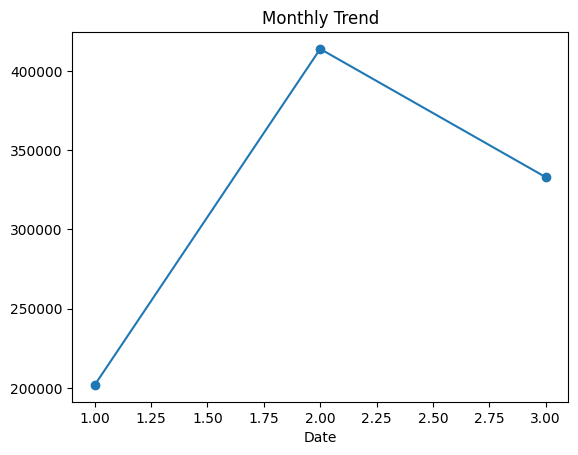

In [9]:
monthly = df.groupby(df["Date"].dt.month)["Amount"].sum()
monthly.plot(marker="o", title="Monthly Trend")
plt.show()